In [27]:
import pandas as pd 

train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

In [28]:
print(train_data.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


In [29]:
print(test_data.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0013_01      Earth      True  G/3/S  TRAPPIST-1e  27.0  False   
1     0018_01      Earth     False  F/4/S  TRAPPIST-1e  19.0  False   
2     0019_01     Europa      True  C/0/S  55 Cancri e  31.0  False   
3     0021_01     Europa     False  C/1/S  TRAPPIST-1e  38.0  False   
4     0023_01      Earth     False  F/5/S  TRAPPIST-1e  20.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck              Name  
0          0.0        0.0           0.0     0.0     0.0   Nelly Carsoning  
1          0.0        9.0           0.0  2823.0     0.0    Lerome Peckers  
2          0.0        0.0           0.0     0.0     0.0   Sabih Unhearfus  
3          0.0     6652.0           0.0   181.0   585.0  Meratz Caltilter  
4         10.0        0.0         635.0     0.0     0.0   Brence Harperez  


### __EDA__

In [30]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [31]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [ ]:
train_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


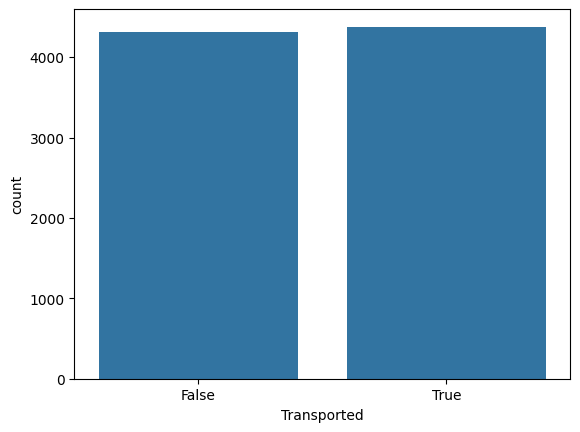

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Transported', data=train_data)
plt.show()

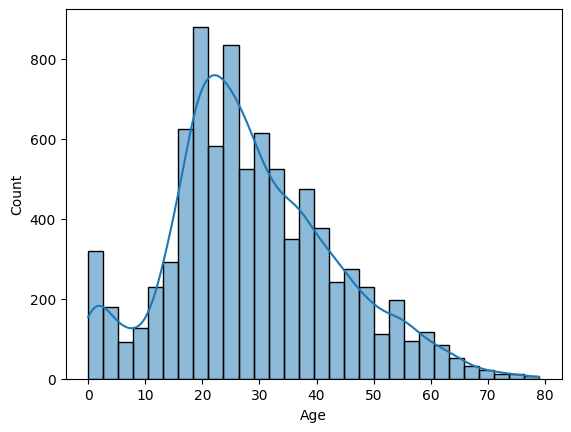

In [ ]:
# Age distribution
sns.histplot(train_data['Age'], bins=30, kde=True)
plt.show()



### __PREPROCESSING__

In [ ]:
# Age: fill missing with median
train_data['Age'].fillna(train_data['Age'].median(), inplace=True)
test_data['Age'].fillna(train_data['Age'].median(), inplace=True)

# VIP: fill missing with False
train_data['VIP'].fillna(False, inplace=True)
test_data['VIP'].fillna(False, inplace=True)

# CryoSleep: fill missing with False
train_data['CryoSleep'].fillna(False, inplace=True)
test_data['CryoSleep'].fillna(False, inplace=True)

# Cabin: extract Deck, Num, Side
def split_cabin(df):
    df['Deck'] = df['Cabin'].apply(lambda x: str(x).split('/')[0])
    df['CabinNum'] = df['Cabin'].apply(lambda x: str(x).split('/')[1] if pd.notnull(x) else 0)
    df['Side'] = df['Cabin'].apply(lambda x: str(x).split('/')[2] if pd.notnull(x) else 'S')
    df['CabinNum'] = df['CabinNum'].astype(int)
    return df

train = split_cabin(train_data)
test = split_cabin(test_data)

# Drop original Cabin
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)

/var/folders/k_/1dkftp8s271534w7nng76kzw0000gn/T/ipykernel_1610/2693159036.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data['VIP'].fillna(False, inplace=True)
/var/folders/k_/1dkftp8s271534w7nng76kzw0000gn/T/ipykernel_1610/2693159036.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data['VIP'].fillna(False, inplace=True)
/var/folders/k_/1dkftp8s271534w7nng76kzw0000gn/T/ipykernel_1610/2693159036.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call res

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in ['HomePlanet', 'Destination', 'Deck', 'Side']:
    train[col].fillna('Unknown', inplace=True)
    test[col].fillna('Unknown', inplace=True)
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]], axis=0))
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])


for col in ['CryoSleep', 'VIP']:
    train[col] = train[col].astype(int)
    test[col] = test[col].astype(int)

### __TRAINNING/TESTING__

In [43]:
from sklearn.model_selection import train_test_split

X = train.drop(['PassengerId','Name','Transported'], axis=1)
y = train['Transported'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.7987349051178838


### __SUBMISSION TO CSV__

In [47]:

X_test = test.drop(['PassengerId','Name'], axis=1)

try:
    train_cols = X_train.columns
except NameError:
    raise NameError("X_train is not defined. Make sure you ran the training/preprocessing cells before this one.")

missing = set(train_cols) - set(X_test.columns)
extra = set(X_test.columns) - set(train_cols)
print(f'X_test shape: {X_test.shape}, expected cols: {len(train_cols)}')
print('Missing columns in X_test:', missing)
print('Extra columns in X_test:', extra)

if missing:
    raise ValueError(f"X_test is missing columns required by the model: {sorted(missing)}")

X_test = X_test.reindex(columns=train_cols).fillna(0)

predictions = model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': predictions.astype(bool)
})

submission.to_csv('submission.csv', index=False)
print("Wrote submission.csv (first 5 rows):")
print(submission.head())

X_test shape: (8693, 14), expected cols: 13
Missing columns in X_test: set()
Extra columns in X_test: {'Transported'}
Wrote submission.csv (first 5 rows):
  PassengerId  Transported
0     0001_01        False
1     0002_01         True
2     0003_01        False
3     0003_02        False
4     0004_01         True
